In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier



Data loading

In [2]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


show 5 first and last row 

In [3]:
a=df.head()
b=df.tail()
print("first 5 row :\n\n", a)
print("last 5 row :\n\n",b)

first 5 row :

    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

data manipulation


In [4]:
print(df.isnull())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

count how many null values in this data base

In [5]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


fill missing age value with mean

In [6]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


fill  missing value in embarked values with mode

In [7]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


drop cabin 

In [10]:
df.drop("Cabin",axis=1, inplace=True)
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


Convert Sex Column 

In [31]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,NaN,22.000000,1,0,7.2500,NaN
1,1,1,NaN,38.000000,1,0,71.2833,NaN
2,1,3,NaN,26.000000,0,0,7.9250,NaN
3,1,1,NaN,35.000000,1,0,53.1000,NaN
4,0,3,NaN,35.000000,0,0,8.0500,NaN
...,...,...,...,...,...,...,...,...
886,0,2,NaN,27.000000,0,0,13.0000,NaN
887,1,1,NaN,19.000000,0,0,30.0000,NaN
888,0,3,NaN,29.699118,1,2,23.4500,NaN
889,1,1,NaN,26.000000,0,0,30.0000,NaN


Convert Embarked Column

In [ ]:
df["Embarked"]=df["Embarked"].map({"S":0,"C":1,"Q":2
})
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,NaN,22.000000,1,0,7.2500,NaN
1,1,1,NaN,38.000000,1,0,71.2833,NaN
2,1,3,NaN,26.000000,0,0,7.9250,NaN
3,1,1,NaN,35.000000,1,0,53.1000,NaN
4,0,3,NaN,35.000000,0,0,8.0500,NaN
...,...,...,...,...,...,...,...,...
886,0,2,NaN,27.000000,0,0,13.0000,NaN
887,1,1,NaN,19.000000,0,0,30.0000,NaN
888,0,3,NaN,29.699118,1,2,23.4500,NaN
889,1,1,NaN,26.000000,0,0,30.0000,NaN


Drop Unwanted Columns

In [ ]:
df.drop(
    ["Name","Ticket","Cabin","PassengerId"],axis=1,inplace=True,
    errors='ignore'
)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,NaN,22.000000,1,0,7.2500,NaN
1,1,1,NaN,38.000000,1,0,71.2833,NaN
2,1,3,NaN,26.000000,0,0,7.9250,NaN
3,1,1,NaN,35.000000,1,0,53.1000,NaN
4,0,3,NaN,35.000000,0,0,8.0500,NaN
...,...,...,...,...,...,...,...,...
886,0,2,NaN,27.000000,0,0,13.0000,NaN
887,1,1,NaN,19.000000,0,0,30.0000,NaN
888,0,3,NaN,29.699118,1,2,23.4500,NaN
889,1,1,NaN,26.000000,0,0,30.0000,NaN


Features and Target

In [ ]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

print(x)
print(y)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3  NaN  22.000000      1      0   7.2500       NaN
1         1  NaN  38.000000      1      0  71.2833       NaN
2         3  NaN  26.000000      0      0   7.9250       NaN
3         1  NaN  35.000000      1      0  53.1000       NaN
4         3  NaN  35.000000      0      0   8.0500       NaN
..      ...  ...        ...    ...    ...      ...       ...
886       2  NaN  27.000000      0      0  13.0000       NaN
887       1  NaN  19.000000      0      0  30.0000       NaN
888       3  NaN  29.699118      1      2  23.4500       NaN
889       1  NaN  26.000000      0      0  30.0000       NaN
890       3  NaN  32.000000      0      0   7.7500       NaN

[891 rows x 7 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


Split Data

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,
    random_state=42
)
print(x)
print(y)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3  NaN  22.000000      1      0   7.2500       NaN
1         1  NaN  38.000000      1      0  71.2833       NaN
2         3  NaN  26.000000      0      0   7.9250       NaN
3         1  NaN  35.000000      1      0  53.1000       NaN
4         3  NaN  35.000000      0      0   8.0500       NaN
..      ...  ...        ...    ...    ...      ...       ...
886       2  NaN  27.000000      0      0  13.0000       NaN
887       1  NaN  19.000000      0      0  30.0000       NaN
888       3  NaN  29.699118      1      2  23.4500       NaN
889       1  NaN  26.000000      0      0  30.0000       NaN
890       3  NaN  32.000000      0      0   7.7500       NaN

[891 rows x 7 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


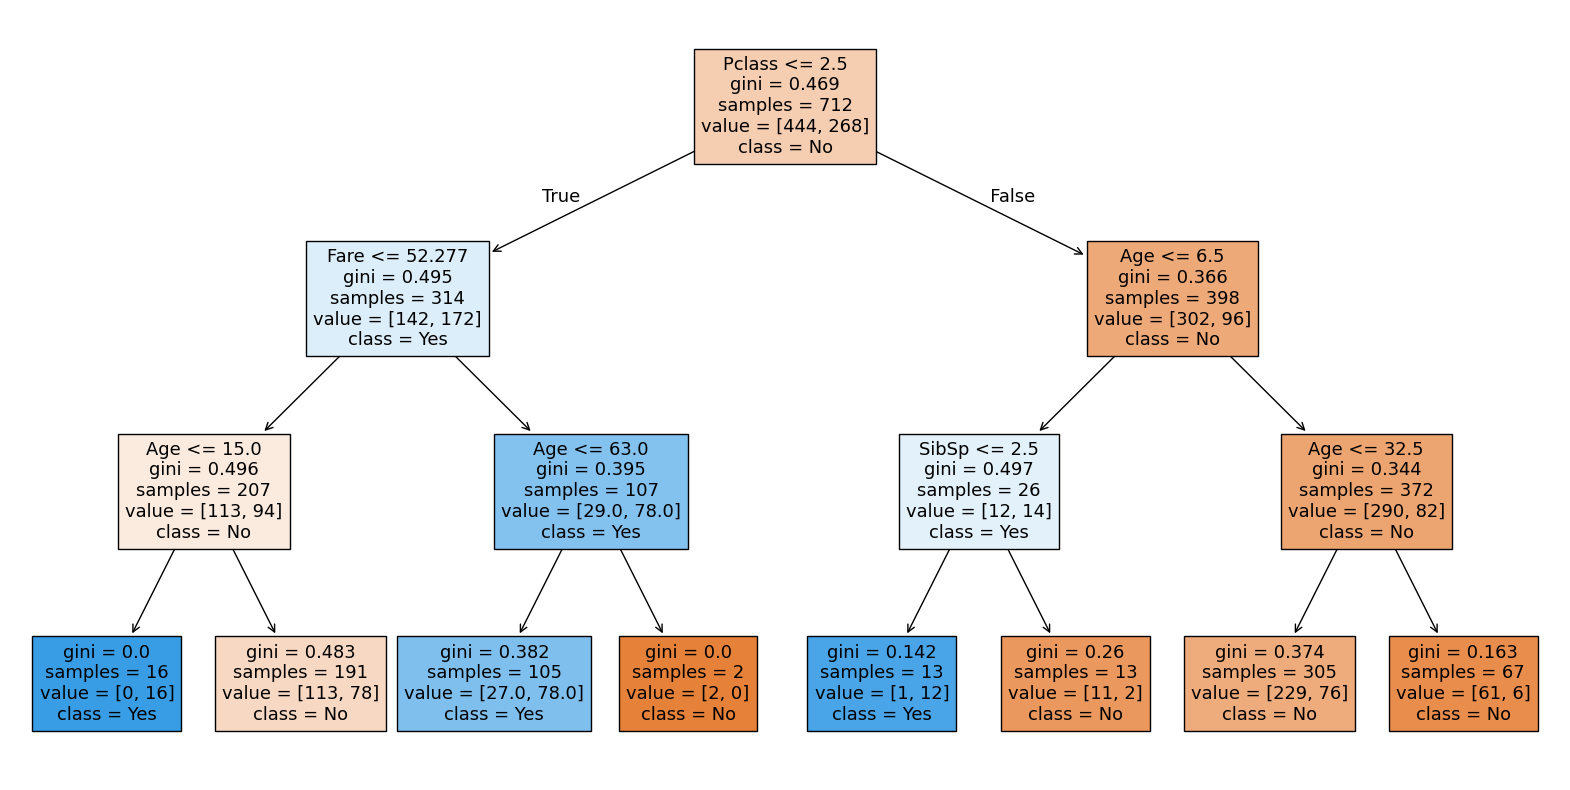

In [36]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(x_train, y_train)
plt.figure(figsize=(20,10))
tree.plot_tree(
    model,filled=True,feature_names=x.columns,class_names=["No","Yes"]
)

plt.show()

 Random forest model

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


Train Model

In [ ]:
model.fit(x_train, y_train)

prediction and accuracy

In [ ]:
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

classification report

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
RandomForestClassifier( n_estimators=100,max_depth=5)